# Metrics Development

## 1. Setup

Imports and shared helpers used throughout the notebook.

In [61]:
import json
import re
import numpy as np
import matplotlib.pyplot as plt
import umap
from pathlib import Path
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors

data_path = "../outputs/%s/embeddings/"


## 2. Single-Run Exploration

### 2.1 Load data

Analyse the projections and labels produced by a single training run.

Edit `run_directory` in the first cell to point at any output folder.

In [62]:
# Specify the run directory
run_directory='/home/markusbredberg/Scripts/p3_suplat/outputs/run_20260331_1621_efficient_wclosest_p0.5'

# Extract the run name from the directory path
run_name = Path(run_directory).name

# Extract project_location (here home/markusbredberg/Scripts/p3_suplat/)
project_location = Path(run_directory).parent.parent

# Load test data
test_proj = np.load(data_path % run_name + "test_projections.npy")                                         
test_labels = np.load(data_path % run_name + "test_labels.npy")  
print("test_proj shape:", test_proj.shape)
print("test_labels shape:", test_labels.shape)

test_proj shape: (30, 256)
test_labels shape: (30, 20)


### 2.2 Class masks
Build boolean masks isolating FRI-only, FRII-only, and Hybrid sources from the multi-label array.

In [63]:
# Mask for FRI only, FRII only, and hybrid
mask_fri = (test_labels[:,0] == 1) & (test_labels[:,1] == 0) & (test_labels[:,2] == 0)
mask_frii = (test_labels[:,0] == 0) & (test_labels[:,1] == 1) & (test_labels[:,2] == 0)
mask_hybrid = test_labels[:, 2] == 1 #OK

# Combine them
combined_mask = mask_fri | mask_frii | mask_hybrid
print(mask_fri.shape, combined_mask.shape)

(30,) (30,)


### 2.3 Clustering metrics
Silhouette score, Davies-Bouldin index, and Calinski-Harabasz score on the test projections. Higher silhouette / Calinski-Harabasz and lower Davies-Bouldin indicate better-separated clusters.

In [64]:
#the labels are in the format of a one-hot encoding, so we need to convert them to a single label for each class
test_labels_single = np.argmax(test_labels[combined_mask], axis=1)

silhouette = silhouette_score(test_proj[combined_mask], test_labels_single)
print("Silhouette Score:", silhouette)

davies_bouldin = davies_bouldin_score(test_proj[combined_mask], test_labels_single)
print("Davies-Bouldin Score:", davies_bouldin)

calinski_harabasz = calinski_harabasz_score(test_proj[combined_mask], test_labels_single)
print("Calinski-Harabasz Score:", calinski_harabasz)

Silhouette Score: -0.09932708740234375
Davies-Bouldin Score: 3.962283235048002
Calinski-Harabasz Score: 4.514409802268646


### 2.4 Pairwise distance distributions
Histograms of embedding distances between every pair of class combinations (FRI–FRII, FRI–Hybrid, FRII–Hybrid). A well-trained model should show clear separation.

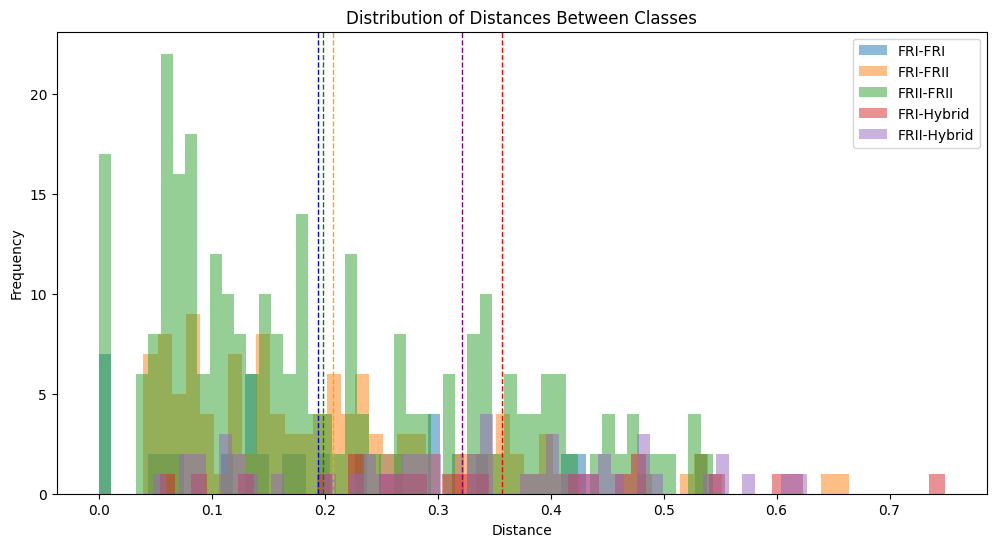

In [65]:
#Show the distribution of distance between FRI-FRII pairs, FRI-hybrid pairs, and FRII-hybrid pairs
# Compute pairwise distances
distances = squareform(pdist(test_proj[combined_mask]))
# Get indices for each class
indices_fri = np.where(test_labels_single == 0)[0]
indices_frii = np.where(test_labels_single == 1)[0]
indices_hybrid = np.where(test_labels_single == 2)[0]
# Compute distances for each pair type
dist_fri_fri = distances[np.ix_(indices_fri, indices_fri)].flatten()
dist_fri_frii = distances[np.ix_(indices_fri, indices_frii)].flatten()
dist_frii_frii = distances[np.ix_(indices_frii, indices_frii)].flatten()
dist_fri_hybrid = distances[np.ix_(indices_fri, indices_hybrid)].flatten()
dist_frii_hybrid = distances[np.ix_(indices_frii, indices_hybrid)].flatten()
# Plot histograms
plt.figure(figsize=(12, 6))
plt.hist(dist_fri_fri, bins=50, alpha=0.5, label='FRI-FRI')
plt.hist(dist_fri_frii, bins=50, alpha=0.5, label='FRI-FRII')
plt.hist(dist_frii_frii, bins=50, alpha=0.5, label='FRII-FRII')
plt.hist(dist_fri_hybrid, bins=50, alpha=0.5, label='FRI-Hybrid')
plt.hist(dist_frii_hybrid, bins=50, alpha=0.5, label='FRII-Hybrid')

# Add mean lines
plt.axvline(np.mean(dist_fri_fri), color='blue', linestyle='dashed', linewidth=1)
plt.axvline(np.mean(dist_fri_frii), color='orange', linestyle='dashed', linewidth=1)
plt.axvline(np.mean(dist_frii_frii), color='green', linestyle='dashed', linewidth=1)
plt.axvline(np.mean(dist_fri_hybrid), color='red', linestyle='dashed', linewidth=1)
plt.axvline(np.mean(dist_frii_hybrid), color='purple', linestyle='dashed', linewidth=1)

plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Distribution of Distances Between Classes')
plt.legend()
plt.show()

## 3. Dimensionality Reduction

### 3.1 Interactive UMAP viewer

Visualise the learned embedding space in 2-D using UMAP and t-SNE.

Colour encodes morphological class; the gold-bordered point marks the query anchor in the KNN gallery.

/home/markusbredberg/Scripts/p3_suplat/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


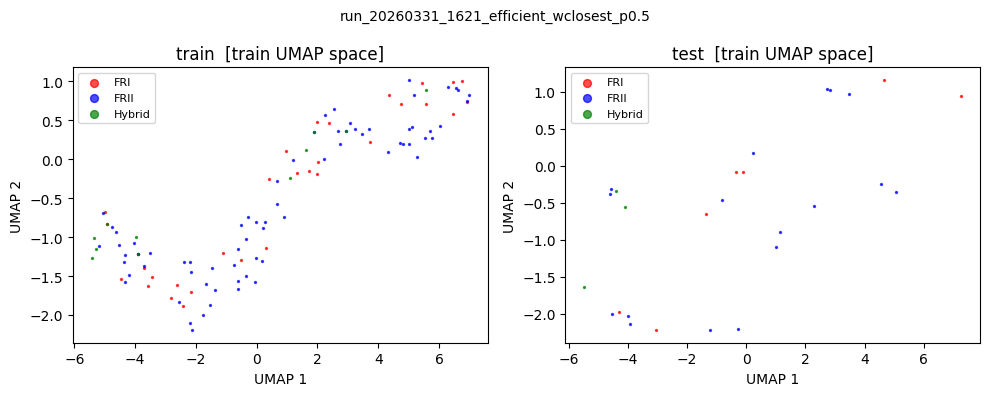

In [66]:
# =============================================================================
# Interactive UMAP viewer
# -----------------------------------------------------------------------------
# splits        : list of splits to show — any subset of ['train', 'val', 'test']
# use_train_umap: if True, fit UMAP on train and *transform* val/test into the
#                 same space (comparable axes); if False, fit each split independently
# run_name      : folder name inside outputs/
# n_neighbors, min_dist : UMAP hyperparameters
# =============================================================================

splits         = ['train', 'test']   # e.g. ['train'], ['val', 'test'], ['train', 'val', 'test']
use_train_umap = True
run_directory='/home/markusbredberg/Scripts/p3_suplat/outputs/run_20260331_1621_efficient_wclosest_p0.5'
n_neighbors    = 30
min_dist       = 0.1

# -----------------------------------------------------------------------------
run_name = Path(run_directory).name
embed_dir = Path("../outputs") / run_name / "embeddings"

split_files = {
    'train': ('train_projections.npy', 'train_labels.npy'),
    'val':   ('val_projections.npy',   'val_labels.npy'),
    'test':  ('test_projections.npy',  'test_labels.npy'),
}

def pure_mask(labels):
    """Boolean mask for FRI-only, FRII-only, and Hybrid rows."""
    fri    = (labels[:, 0] == 1) & (labels[:, 1] == 0) & (labels[:, 2] == 0)
    frii   = (labels[:, 0] == 0) & (labels[:, 1] == 1) & (labels[:, 2] == 0)
    hybrid =  labels[:, 2] == 1
    return fri | frii | hybrid

# Load requested splits
data = {}
for s in splits:
    proj_file, lbl_file = split_files[s]
    proj   = np.load(embed_dir / proj_file)
    labels = np.load(embed_dir / lbl_file)
    mask   = pure_mask(labels)
    data[s] = {'proj': proj, 'labels': labels, 'mask': mask}

# Fit UMAP
if use_train_umap:
    if 'train' not in data:
        raise ValueError("use_train_umap=True requires 'train' in splits")
    train_proj_masked = data['train']['proj'][data['train']['mask']]
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist,
                        metric='euclidean', random_state=42)
    data['train']['embedding'] = reducer.fit_transform(train_proj_masked)
    for s in splits:
        if s == 'train':
            continue
        data[s]['embedding'] = reducer.transform(data[s]['proj'][data[s]['mask']])
else:
    for s in splits:
        data[s]['embedding'] = UMAP_embedding(
            data[s]['proj'][data[s]['mask']], n_neighbors=n_neighbors, min_dist=min_dist
        )

# Plot
fig, axes = plt.subplots(1, len(splits), figsize=(5 * len(splits), 4), squeeze=False)
axes = axes[0]

colors = {'FRI': 'red', 'FRII': 'blue', 'Hybrid': 'green'}
umap_label = "train UMAP space" if use_train_umap else "independent UMAP"

for ax, s in zip(axes, splits):
    emb    = data[s]['embedding']
    labels = data[s]['labels'][data[s]['mask']]
    ax.scatter(emb[labels[:, 0] == 1, 0], emb[labels[:, 0] == 1, 1],
               c=colors['FRI'],    s=2, alpha=0.7, label='FRI')
    ax.scatter(emb[labels[:, 1] == 1, 0], emb[labels[:, 1] == 1, 1],
               c=colors['FRII'],   s=2, alpha=0.7, label='FRII')
    ax.scatter(emb[labels[:, 2] == 1, 0], emb[labels[:, 2] == 1, 1],
               c=colors['Hybrid'], s=2, alpha=0.7, label='Hybrid')
    ax.set_title(f"{s}  [{umap_label}]")
    ax.legend(markerscale=4, fontsize=8)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")

fig.suptitle(run_name, fontsize=10)
plt.tight_layout()
plt.show()


### 3.2 UMAP helper & hyperparameter sweep
Wraps `umap.UMAP` in a single callable. The sweep below varies `min_dist` to find a visually informative layout.

/home/markusbredberg/Scripts/p3_suplat/.venv/lib/python3.12/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(
/home/markusbredberg/Scripts/p3_suplat/.venv/lib/python3.12/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


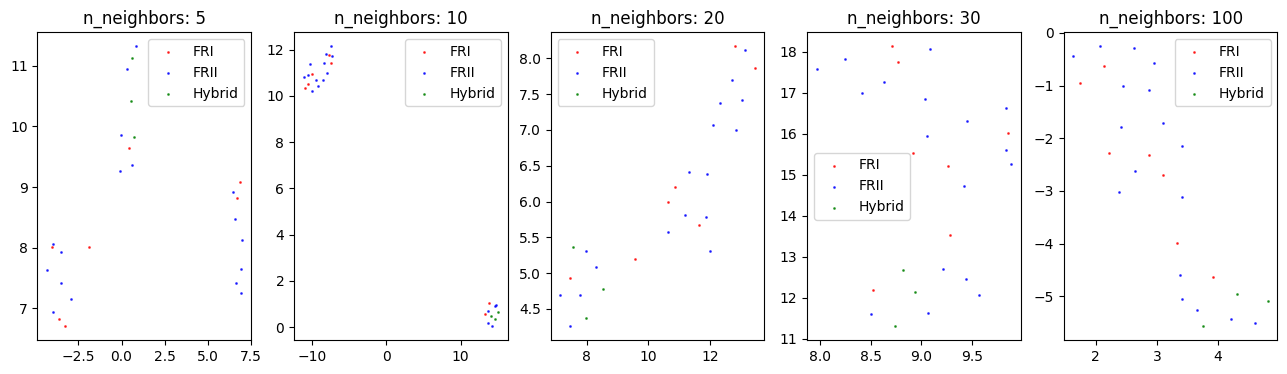

In [67]:
#test umap-learn by varying the n_neighbors and min_dist parameters

def UMAP_embedding(embeddings, n_neighbors=15, min_dist=0.1):
    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric='euclidean'
    )
    embedding_2d = reducer.fit_transform(embeddings)
    return embedding_2d

# Make 5 subplots varying n_neighbors

n_neighbors_values = [5, 10, 20, 30, 100]

plt.figure(figsize=(16, 4))
for i, n_neighbors in enumerate(n_neighbors_values):
    embedding_2d = UMAP_embedding(test_proj[combined_mask], n_neighbors=n_neighbors, min_dist=0.1)
    plt.subplot(1, 5, i + 1)
    scatter = plt.scatter(embedding_2d[test_labels_single == 0, 0], embedding_2d[test_labels_single == 0, 1], c='red', label='FRI', alpha=0.7, s=1)
    scatter = plt.scatter(embedding_2d[test_labels_single == 1, 0], embedding_2d[test_labels_single == 1, 1], c='blue', label='FRII', alpha=0.7, s=1)
    scatter = plt.scatter(embedding_2d[test_labels_single == 2, 0], embedding_2d[test_labels_single == 2, 1], c='green', label='Hybrid', alpha=0.7, s=1)
    plt.legend()
    plt.title(f'n_neighbors: {n_neighbors}')
plt.show()

### 3.3 `min_dist` sweep
Five projections with `min_dist` ∈ {0.01, 0.05, 0.1, 0.5, 0.9} at fixed `n_neighbors=50`. Smaller values pack clusters tighter; larger values preserve global topology.

/home/markusbredberg/Scripts/p3_suplat/.venv/lib/python3.12/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(
/home/markusbredberg/Scripts/p3_suplat/.venv/lib/python3.12/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(
/home/markusbredberg/Scripts/p3_suplat/.venv/lib/python3.12/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(
/home/markusbredberg/Scripts/p3_suplat/.venv/lib/python3.12/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


/home/markusbredberg/Scripts/p3_suplat/.venv/lib/python3.12/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


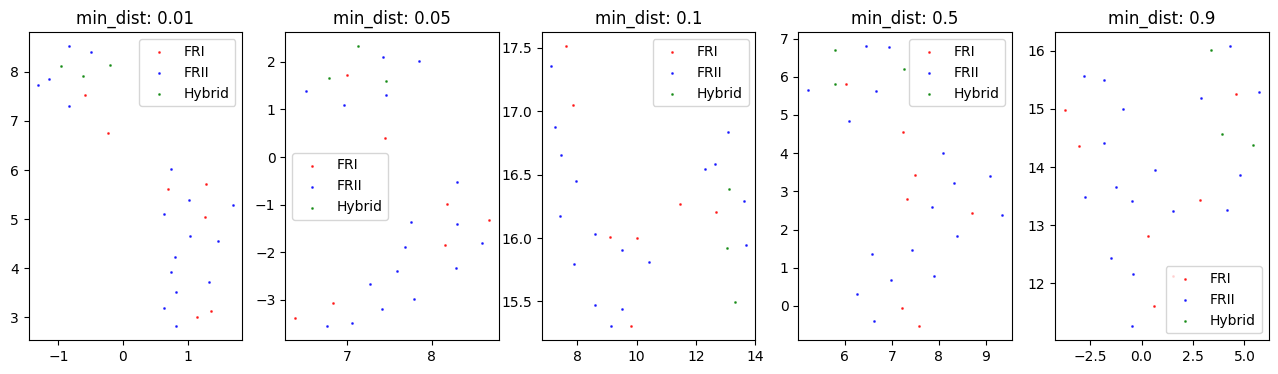

In [68]:
# Make 5 subplots varying min_dist
min_dist_values = [0.01, 0.05, 0.1, 0.5, 0.9]
plt.figure(figsize=(16, 4))
for i, min_dist in enumerate(min_dist_values):
    embedding_2d = UMAP_embedding(test_proj[combined_mask], n_neighbors=50, min_dist=min_dist)
    plt.subplot(1, 5, i + 1)
    scatter = plt.scatter(embedding_2d[test_labels_single == 0, 0], embedding_2d[test_labels_single == 0, 1], c='red', label='FRI', alpha=0.7, s=1)
    scatter = plt.scatter(embedding_2d[test_labels_single == 1, 0], embedding_2d[test_labels_single == 1, 1], c='blue', label='FRII', alpha=0.7, s=1)
    scatter = plt.scatter(embedding_2d[test_labels_single == 2, 0], embedding_2d[test_labels_single == 2, 1], c='green', label='Hybrid', alpha=0.7, s=1)
    plt.legend()
    plt.title(f'min_dist: {min_dist}')
plt.show()

### 3.4 Best-case projections — train vs test
UMAP at the best hyperparameters (`n_neighbors=30`, `min_dist=0.1`) for both the *both* and *either* loss variants. Train is shown at full size, 2 400, and 1 000 samples to check for density effects.

(30,) (114,)


/home/markusbredberg/Scripts/p3_suplat/.venv/lib/python3.12/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


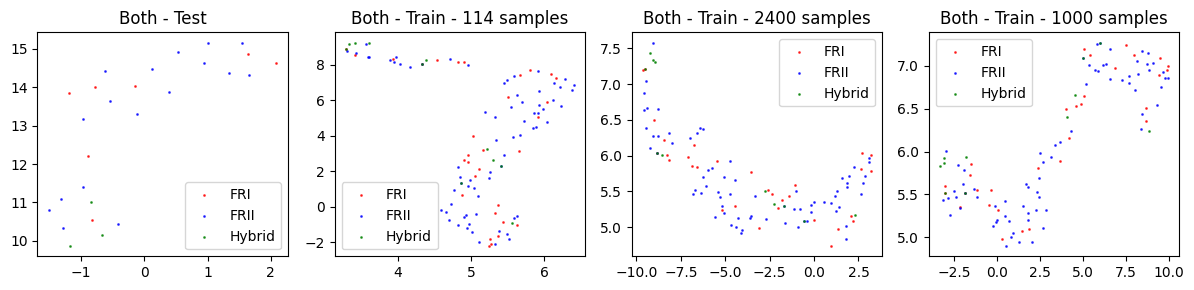

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  56  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72  73  74
  75  76  78  79  80  81  82  83  85  86  87  88  89  90  91  92  93  94
  95  96  97  98  99 100 101 102 103 104 105 106 107 108 109 110 111 112]
[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True False  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True False  True False  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True False  True  True  True  True  True  True
 False  True  True  True  True  True  True  True  

In [69]:
# Now let's do the UMAPs for the best cases of both and either. We take n_neighbors=30 and min_dist=0.1.
# We do on the train and on the test. We vary the number of samples on train from all to the same number as test.
n_neighbors = 30
min_dist = 0.1
#First for both, best is with w=10
test_proj_both = np.load(data_path % run_name + "test_projections.npy")
test_labels_both = np.load(data_path % run_name + "test_labels.npy")
train_proj_both = np.load(data_path % run_name + "train_projections.npy")
train_labels_both = np.load(data_path % run_name + "train_labels.npy")

#compute the combined mask for train and test
mask_fri_test = (test_labels_both[:,0] == 1) & (test_labels_both[:,1] == 0) & (test_labels_both[:,2] == 0)
mask_frii_test = (test_labels_both[:,0] == 0 ) & (test_labels_both[:,1] == 1) & (test_labels_both[:,2] == 0)
mask_hybrid_test = test_labels_both[:, 2] == 1 #OK
mask_fri_train = (train_labels_both[:,0] == 1) & (train_labels_both[:,1] == 0) & (train_labels_both[:,2] == 0)
mask_frii_train = (train_labels_both[:,0] == 0) & (train_labels_both[:,1] == 1) & (train_labels_both[:,2] == 0)
mask_hybrid_train = train_labels_both[:, 2] == 1 #OK
combined_mask_test = mask_fri_test | mask_frii_test | mask_hybrid_test
combined_mask_train = mask_fri_train | mask_frii_train | mask_hybrid_train
print(combined_mask_test.shape, combined_mask_train.shape)
#run Umap on test and train
embedding_2d_test_both = UMAP_embedding(test_proj_both[combined_mask_test], n_neighbors=n_neighbors, min_dist=min_dist)
embedding_2d_train_both = UMAP_embedding(train_proj_both[combined_mask_train], n_neighbors=n_neighbors, min_dist=min_dist)
#plot
plt.figure(figsize=(12, 3))
plt.subplot(1, 4, 1)
scatter = plt.scatter(embedding_2d_test_both[test_labels_both[combined_mask_test][:,0] == 1, 0], embedding_2d_test_both[test_labels_both[combined_mask_test][:,0] == 1, 1], c='red', label='FRI', alpha=0.7, s=1)
scatter = plt.scatter(embedding_2d_test_both[test_labels_both[combined_mask_test][:,1] == 1, 0], embedding_2d_test_both[test_labels_both[combined_mask_test][:,1] == 1, 1], c='blue', label='FRII', alpha=0.7, s=1)
scatter = plt.scatter(embedding_2d_test_both[test_labels_both[combined_mask_test][:,2] == 1, 0], embedding_2d_test_both[test_labels_both[combined_mask_test][:,2] == 1, 1], c='green', label='Hybrid', alpha=0.7, s=1)
plt.legend()
plt.title(f'Both - Test')
# Now do it for train, full sample, 2400 random samples and 1200 random samples
for i, n_samples in enumerate([combined_mask_train.shape[0], 2400, 1000]):
    if n_samples < combined_mask_train.shape[0]:
        indices = np.random.choice(np.where(combined_mask_train)[0], size=n_samples, replace=False)
    else:
        indices = np.where(combined_mask_train)[0]
    embedding_2d_train_both_sample = UMAP_embedding(train_proj_both[indices], n_neighbors=n_neighbors, min_dist=min_dist)
    plt.subplot(1, 4, i + 2)
    scatter = plt.scatter(embedding_2d_train_both_sample[train_labels_both[indices][:,0] == 1, 0], embedding_2d_train_both_sample[train_labels_both[indices][:,0] == 1, 1], c='red', label='FRI', alpha=0.7, s=1)
    scatter = plt.scatter(embedding_2d_train_both_sample[train_labels_both[indices][:,1] == 1, 0], embedding_2d_train_both_sample[train_labels_both[indices][:,1] == 1, 1], c='blue', label='FRII', alpha=0.7, s=1)
    scatter = plt.scatter(embedding_2d_train_both_sample[train_labels_both[indices][:,2] == 1, 0], embedding_2d_train_both_sample[train_labels_both[indices][:,2] == 1, 1], c='green', label='Hybrid', alpha=0.7, s=1)
    plt.legend()
    plt.title(f'Both - Train - {n_samples} samples')
plt.tight_layout()
plt.show()

print(np.where(combined_mask_train)[0])
print(combined_mask_train)

### 3.5 t-SNE comparison
t-SNE (`perplexity=25`) on the same embeddings as §3.4 for a second opinion on cluster structure. t-SNE is more expensive but can reveal finer local neighbourhood detail.

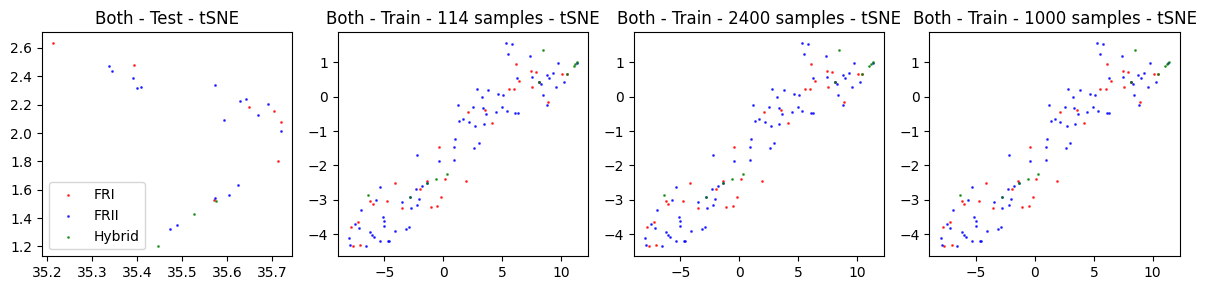

In [70]:
#try tSNE on the same data: sklearn.manifold.TSNE
embedding_2d_test_both_tsne = TSNE(n_components=2, perplexity=25).fit_transform(test_proj_both[combined_mask_test])
embedding_2d_train_both_tsne = TSNE(n_components=2, perplexity=25).fit_transform(train_proj_both[combined_mask_train])
#plot
plt.figure(figsize=(12, 3))
plt.subplot(1, 4, 1)
scatter = plt.scatter(embedding_2d_test_both_tsne[test_labels_both[combined_mask_test][:,0] == 1, 0], embedding_2d_test_both_tsne[test_labels_both[combined_mask_test][:,0] == 1, 1], c='red', label='FRI', alpha=0.7, s=1)
scatter = plt.scatter(embedding_2d_test_both_tsne[test_labels_both[combined_mask_test][:,1] == 1, 0], embedding_2d_test_both_tsne[test_labels_both[combined_mask_test][:,1] == 1, 1], c='blue', label='FRII', alpha=0.7, s=1)
scatter = plt.scatter(embedding_2d_test_both_tsne[test_labels_both[combined_mask_test][:,2] == 1, 0], embedding_2d_test_both_tsne[test_labels_both[combined_mask_test][:,2] == 1, 1], c='green', label='Hybrid', alpha=0.7, s=1)
plt.legend()
plt.title('Both - Test - tSNE')
# Now do it for train, full sample, 2400 random samples and 1200 random samples
for i, n_samples in enumerate([combined_mask_train.shape[0], 2400, 1000]):
    if n_samples < combined_mask_train.shape[0]:
        indices = np.random.choice(np.where(combined_mask_train)[0], size=n_samples, replace=False)
    else:
        indices = np.where(combined_mask_train)[0]
    embedding_2d_train_both_sample_tsne = TSNE(n_components=2, perplexity=30).fit_transform(train_proj_both[indices])
    plt.subplot(1, 4, i + 2)
    scatter = plt.scatter(embedding_2d_train_both_sample_tsne[train_labels_both[indices][:,0] == 1, 0], embedding_2d_train_both_sample_tsne[train_labels_both[indices][:,0] == 1, 1], c='red', label='FRI', alpha=0.7, s=1)
    scatter = plt.scatter(embedding_2d_train_both_sample_tsne[train_labels_both[indices][:,1] == 1, 0], embedding_2d_train_both_sample_tsne[train_labels_both[indices][:,1] == 1, 1], c='blue', label='FRII', alpha=0.7, s=1)
    scatter = plt.scatter(embedding_2d_train_both_sample_tsne[train_labels_both[indices][:,2] == 1, 0], embedding_2d_train_both_sample_tsne[train_labels_both[indices][:,2] == 1, 1], c='green', label='Hybrid', alpha=0.7, s=1)
    #plt.legend()
    plt.title(f'Both - Train - {n_samples} samples - tSNE')
plt.tight_layout()
plt.show()

## 4. Nearest-Neighbour & Distance Analysis

### 4.1 KNN image gallery

Quantify how well the embedding space organises sources by morphology.

§4.1 shows raw image neighbours; §4.2–4.3 correlate embedding distance with label overlap.

Run: run_20260331_1621_efficient_wclosest_p0.5  |  split: test


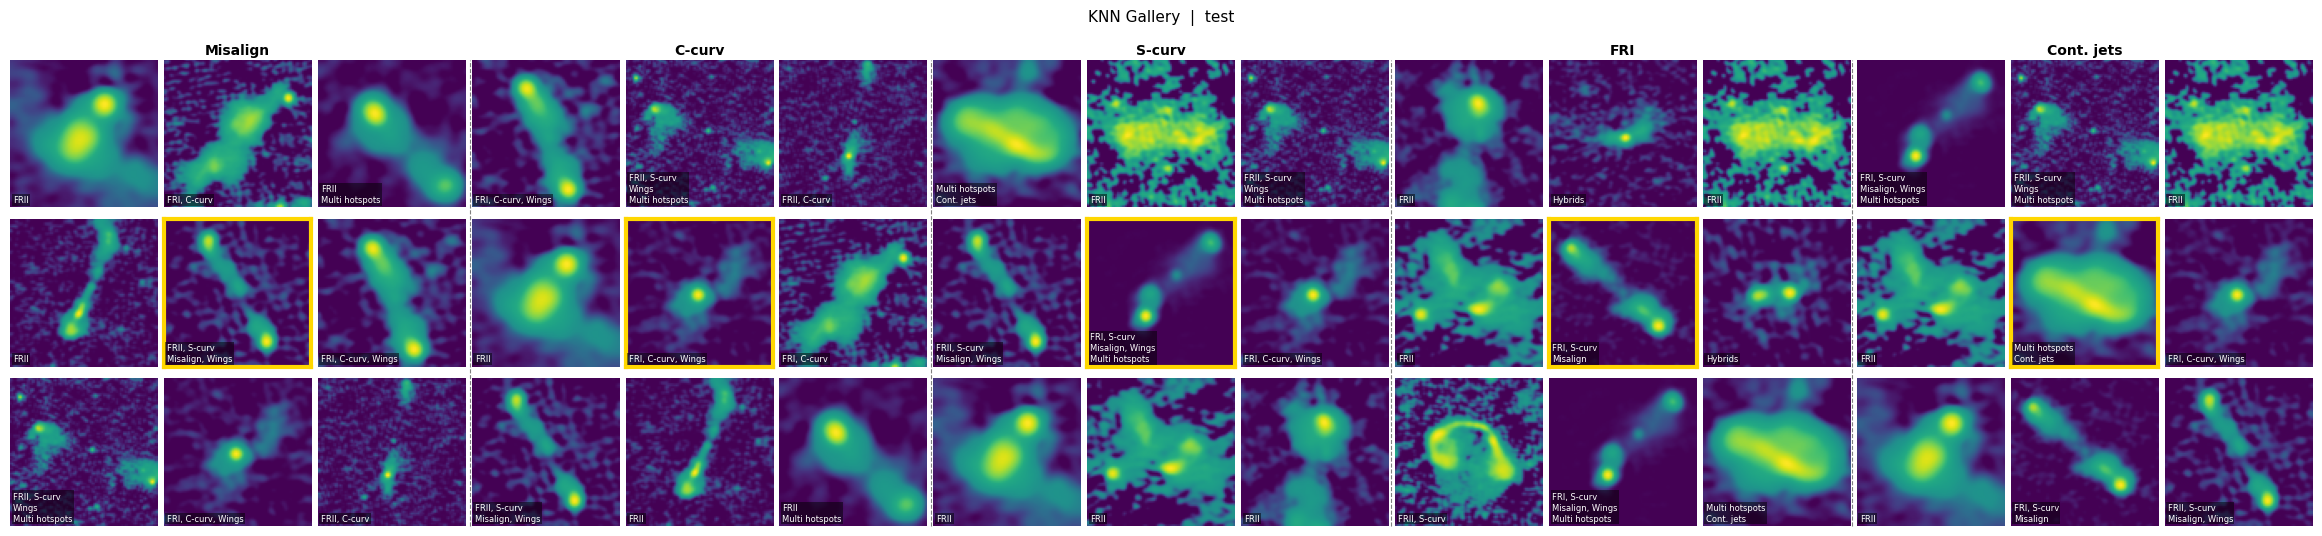

In [71]:
# =============================================================================
# KNN Nearest-Neighbour Gallery
# =============================================================================
split    = 'test'
N        = 5
seed     = 42
# =============================================================================

ALL_CLASS_NAMES = [
    'FRI', 'FRII', 'Hybrids', 'Spirals', 'Relaxed doubles',
    'C-curv', 'S-curv', 'Misalign', 'Wings', 'X-shaped',
    'Straight jets', 'Multi hotspots', 'Cont. jets', 'Banding', 'One-sided', 'Restarted',
    'Cluster', 'Merger', 'Diffuse', 'Unknown',
]

# --- Load data ---
images_full = np.load(f'{project_location}/data/images.npy')

all_idx = np.arange(len(images_full))
train_idx, temp_idx = train_test_split(all_idx, test_size=0.30, random_state=seed)
val_idx,  test_idx  = train_test_split(temp_idx, test_size=0.5,  random_state=seed)
split_idx = {'train': train_idx, 'val': val_idx, 'test': test_idx}[split]
images = images_full[split_idx]

emb_dir     = f'{project_location}/outputs/{run_name}/embeddings/'
projections = np.load(emb_dir + f'{split}_projections.npy')
labels      = np.load(emb_dir + f'{split}_labels.npy')

# --- Sample N classes ---
rng = np.random.default_rng(seed)
positive_counts = (labels == 1).sum(axis=0)
valid_cols   = np.where(positive_counts >= 1)[0]
sampled_cols = rng.choice(valid_cols, size=N, replace=False)

# --- Fit KNN once ---
nn_model = NearestNeighbors(n_neighbors=9, metric='euclidean').fit(projections)

# --- Print run info once, above everything ---
print(f'Run: {run_name}  |  split: {split}')

# --- Helper: wrap a comma-separated label string at max_chars per line ---
def wrap_label(label_str, max_chars=18):
    parts = [s.strip() for s in label_str.split(',')]
    lines, current = [], ''
    for part in parts:
        candidate = f'{current}, {part}' if current else part
        if len(candidate) > max_chars and current:
            lines.append(current)
            current = part
        else:
            current = candidate
    if current:
        lines.append(current)
    return '\n'.join(lines)

# --- Figure layout constants ---
cell_size  = 1.6          # inches per image cell
left_mar   = 0.02         # figure left margin (fraction)
right_mar  = 0.02         # figure right margin (fraction)
top_mar    = 0.10         # space for suptitle + gallery titles
bottom_mar = 0.02

fig_width  = cell_size * 3 * N
fig_height = cell_size * 3 + 0.5   # +0.5 for title row

fig, axes = plt.subplots(
    3, 3 * N,
    figsize=(fig_width, fig_height),
    gridspec_kw={'wspace': 0.03, 'hspace': 0.08}
)

# Explicit margins — avoids tight_layout conflict with Line2D artists
fig.subplots_adjust(
    left=left_mar, right=1 - right_mar,
    top=1 - top_mar, bottom=bottom_mar
)

for i, col in enumerate(sampled_cols):
    # --- Pick anchor and neighbours ---
    anchor_idx = int(rng.choice(np.where(labels[:, col] == 1)[0]))
    _, indices = nn_model.kneighbors(projections[anchor_idx:anchor_idx + 1])
    nn_idxs = indices[0][1:]

    grid_idxs = [nn_idxs[0], nn_idxs[1], nn_idxs[2],
                 nn_idxs[3], anchor_idx,  nn_idxs[4],
                 nn_idxs[5], nn_idxs[6], nn_idxs[7]]

    col_offset = i * 3   # leftmost column index for this gallery

    # --- Gallery title: centred on the middle cell of the top row ---
    axes[0, col_offset + 1].set_title(
        ALL_CLASS_NAMES[col], fontsize=10, fontweight='bold', pad=4
    )

    for flat_pos, data_idx in enumerate(grid_idxs):
        row    = flat_pos // 3
        col_pos = col_offset + (flat_pos % 3)
        ax = axes[row, col_pos]

        ax.imshow(images[data_idx], cmap='viridis', origin='lower')
        ax.axis('off')

        # Golden border on anchor cell
        if data_idx == anchor_idx:
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_edgecolor('gold')
                spine.set_linewidth(3)
            ax.axis('on')
            ax.set_xticks([])
            ax.set_yticks([])

        # Wrapped label overlay
        lbl    = labels[data_idx]
        active = [ALL_CLASS_NAMES[j] for j in range(20) if lbl[j] == 1]
        tag    = wrap_label(', '.join(active)) if active else '—'
        ax.text(
            0.02, 0.02, tag,
            transform=ax.transAxes,
            fontsize=6, color='white',
            va='bottom', ha='left', linespacing=1.3,
            bbox=dict(facecolor='black', alpha=0.5, pad=1, linewidth=0)
        )

    # --- Separator line between galleries ---
    # x position in figure coordinates: map column boundary through plot area
    if i < N - 1:
        plot_width = 1 - left_mar - right_mar          # fraction of figure used by axes
        x_sep = left_mar + plot_width * (col_offset + 3) / (3 * N)
        fig.add_artist(
            plt.matplotlib.lines.Line2D(
                [x_sep, x_sep], [bottom_mar, 1 - top_mar],
                transform=fig.transFigure,
                color='grey', linewidth=0.8, linestyle='--', zorder=10
            )
        )

fig.suptitle(f'KNN Gallery  |  {split}', fontsize=11, y=0.995)
plt.show()

### 4.2 Cosine distance vs Hamming distance
Scatter plot of cosine distance in embedding space against Hamming distance between multi-hot label vectors for up to 300 000 random test-set pairs. A well-trained model should show a positive correlation.

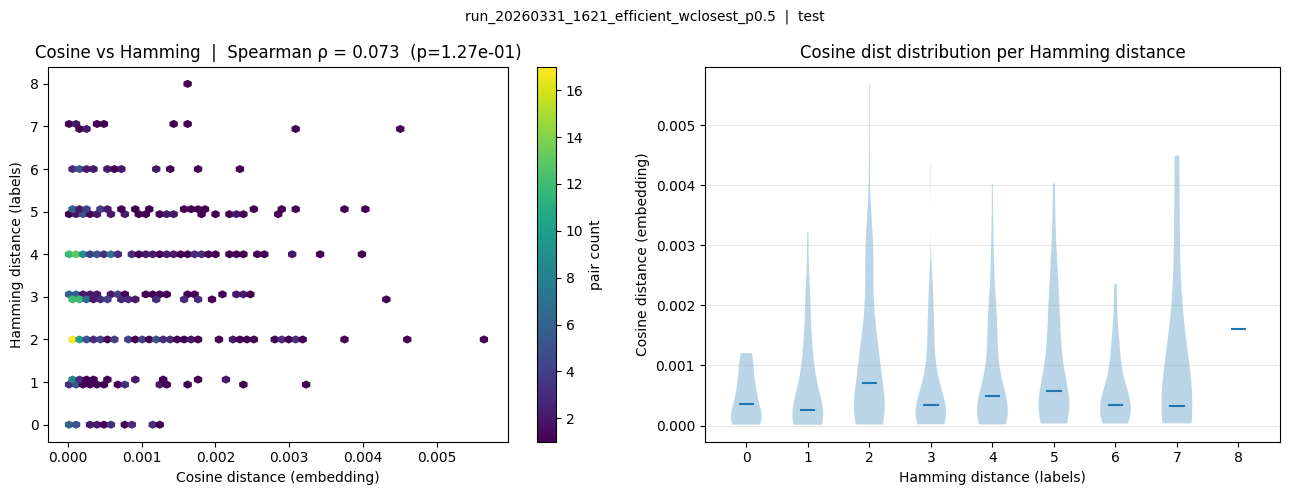

In [72]:
# =============================================================================
# Cosine distance (embedding) vs Hamming distance (labels)
# =============================================================================
split     = 'test'
MAX_PAIRS = 300_000
seed      = 42
# =============================================================================

emb_dir = Path(f'../outputs/{run_name}/embeddings')
proj    = np.load(emb_dir / f'{split}_projections.npy')
labels  = np.load(emb_dir / f'{split}_labels.npy')

cos_d  = pdist(proj,   metric='cosine')
ham_d  = (pdist(labels, metric='hamming') * labels.shape[1]).round().astype(int)

rho, pval = spearmanr(cos_d, ham_d)

rng = np.random.default_rng(seed)
idx = rng.choice(len(cos_d), size=min(MAX_PAIRS, len(cos_d)), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Hexbin
hb = axes[0].hexbin(cos_d[idx], ham_d[idx], gridsize=60, cmap='viridis', mincnt=1)
fig.colorbar(hb, ax=axes[0], label='pair count')
axes[0].set_xlabel('Cosine distance (embedding)')
axes[0].set_ylabel('Hamming distance (labels)')
axes[0].set_title(f'Cosine vs Hamming  |  Spearman ρ = {rho:.3f}  (p={pval:.2e})')

# Violin per Hamming bin
unique_h = sorted(np.unique(ham_d))
data_by_h = [cos_d[ham_d == h] for h in unique_h]
vp = axes[1].violinplot(data_by_h, positions=unique_h, showmedians=True, showextrema=False)
axes[1].set_xlabel('Hamming distance (labels)')
axes[1].set_ylabel('Cosine distance (embedding)')
axes[1].set_title('Cosine dist distribution per Hamming distance')
axes[1].set_xticks(unique_h)
axes[1].grid(axis='y', alpha=0.3)

fig.suptitle(f'{run_name}  |  {split}', fontsize=10)
plt.tight_layout()
plt.show()


### 4.3 Cosine vs Hamming — per-tag filter
Same scatter as §4.2 but restricted to pairs where at least one source carries a specific tag. Adjust `TAG_COL` to inspect any of the 20 morphology classes.

Tag "FRII": 17 samples selected


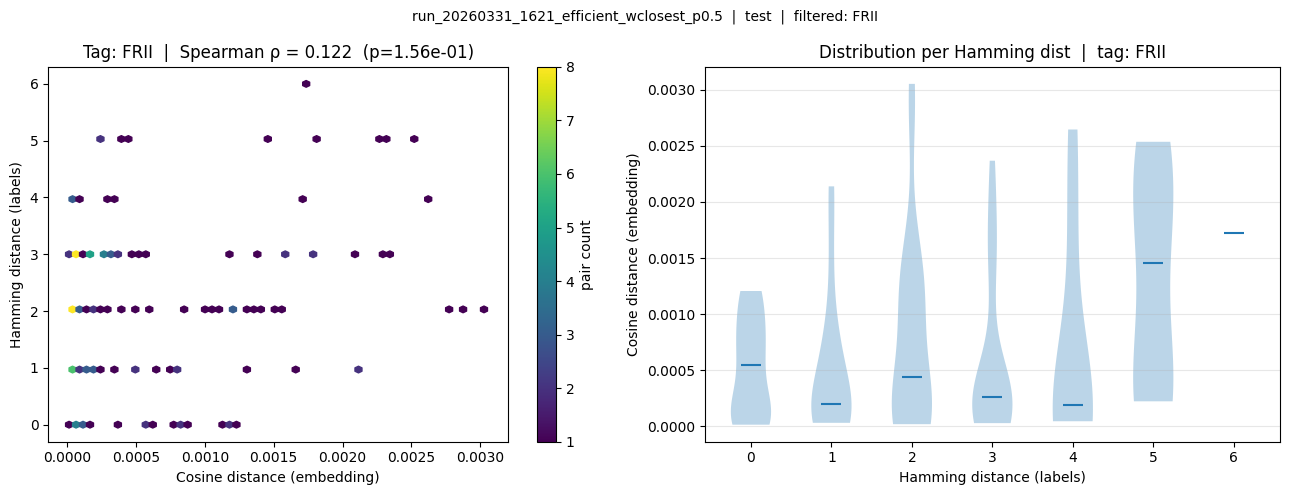

In [73]:
# =============================================================================
# Cosine vs Hamming — filtered to one tag
# =============================================================================
TAG_COL  = 1    # 0=FRI, 1=FRII, 2=Hybrids, 3=Spirals, 4=Relaxed doubles, ...
# (run_name, split, MAX_PAIRS, seed reused from previous cell)
# =============================================================================

ALL_CLASS_NAMES = [
    'FRI', 'FRII', 'Hybrids', 'Spirals', 'Relaxed doubles',
    'C-curv', 'S-curv', 'Misalign', 'Wings', 'X-shaped',
    'Straight jets', 'Multi hotspots', 'Cont. jets', 'Banding', 'One-sided', 'Restarted',
    'Cluster', 'Merger', 'Diffuse', 'Unknown',
]

tag_name = ALL_CLASS_NAMES[TAG_COL]
tag_mask = labels[:, TAG_COL] == 1
proj_tag   = proj[tag_mask]
labels_tag = labels[tag_mask]
print(f'Tag "{tag_name}": {tag_mask.sum()} samples selected')

cos_d_tag = pdist(proj_tag,   metric='cosine')
ham_d_tag = (pdist(labels_tag, metric='hamming') * labels_tag.shape[1]).round().astype(int)

rho_tag, pval_tag = spearmanr(cos_d_tag, ham_d_tag)

idx_tag = rng.choice(len(cos_d_tag), size=min(MAX_PAIRS, len(cos_d_tag)), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

hb = axes[0].hexbin(cos_d_tag[idx_tag], ham_d_tag[idx_tag], gridsize=60, cmap='viridis', mincnt=1)
fig.colorbar(hb, ax=axes[0], label='pair count')
axes[0].set_xlabel('Cosine distance (embedding)')
axes[0].set_ylabel('Hamming distance (labels)')
axes[0].set_title(f'Tag: {tag_name}  |  Spearman ρ = {rho_tag:.3f}  (p={pval_tag:.2e})')

unique_h_tag = sorted(np.unique(ham_d_tag))
data_by_h_tag = [cos_d_tag[ham_d_tag == h] for h in unique_h_tag]
axes[1].violinplot(data_by_h_tag, positions=unique_h_tag, showmedians=True, showextrema=False)
axes[1].set_xlabel('Hamming distance (labels)')
axes[1].set_ylabel('Cosine distance (embedding)')
axes[1].set_title(f'Distribution per Hamming dist  |  tag: {tag_name}')
axes[1].set_xticks(unique_h_tag)
axes[1].grid(axis='y', alpha=0.3)

fig.suptitle(f'{run_name}  |  {split}  |  filtered: {tag_name}', fontsize=10)
plt.tight_layout()
plt.show()


## 5. Multi-Run Comparison

### 5.1 Metric scores by loss weight

Compare clustering quality metrics across a sweep of loss hyperparameters or across entirely different runs.

§5.1 covers the metric-loss weight grid; §5.2–5.3 aggregate arbitrary output directories.

In [74]:
cases_both = [0.01, 0.1, 1, 10]
cases_either = [0, 0.25, 0.5, 0.75]

# compute silhouette, davies bouldin, calinski harabasz for each case, make a plot as a function of the case values
silhouette_scores = np.zeros((2, 4))
davies_bouldin_scores = np.zeros((2, 4))
calinski_harabasz_scores = np.zeros((2, 4))
for i, case in enumerate(cases_both):
    tmp_test_proj = np.load(data_path%f"run_both_w{case}" + "test_projections.npy")
    tmp_test_labels = np.load(data_path%f"run_both_w{case}" + "test_labels.npy")
    # Mask for FRI only, FRII only, and hybrid
    mask_fri = (tmp_test_labels[:,0] == 1) & (tmp_test_labels[:,1] == 0) & (tmp_test_labels[:,2] == 0)
    mask_frii = (tmp_test_labels[:,0] == 0) & (tmp_test_labels[:,1] == 1) & (tmp_test_labels[:,2] == 0)
    mask_hybrid = tmp_test_labels[:, 2] == 1 #OK
    # Combine them
    combined_mask = mask_fri | mask_frii | mask_hybrid
    test_labels_single = np.argmax(tmp_test_labels[combined_mask], axis=1)
    silhouette_scores[0, i] = silhouette_score(tmp_test_proj[combined_mask], test_labels_single)
    davies_bouldin_scores[0, i] = davies_bouldin_score(tmp_test_proj[combined_mask], test_labels_single)
    calinski_harabasz_scores[0, i] = calinski_harabasz_score(tmp_test_proj[combined_mask], test_labels_single)

for i, case in enumerate(cases_either):
    tmp_test_proj = np.load(data_path%f"run_either_p{case}" + "test_projections.npy")
    tmp_test_labels = np.load(data_path%f"run_either_p{case}" + "test_labels.npy")
    # Mask for FRI only, FRII only, and hybrid
    mask_fri = (tmp_test_labels[:,0] == 1) & (tmp_test_labels[:,1] == 0) & (tmp_test_labels[:,2] == 0)
    mask_frii = (tmp_test_labels[:,0] == 0) & (tmp_test_labels[:,1] == 1) & (tmp_test_labels[:,2] == 0)
    mask_hybrid = tmp_test_labels[:, 2] == 1 #OK
    # Combine them
    combined_mask = mask_fri | mask_frii | mask_hybrid
    test_labels_single = np.argmax(tmp_test_labels[combined_mask], axis=1)
    silhouette_scores[1, i] = silhouette_score(tmp_test_proj[combined_mask], test_labels_single)
    davies_bouldin_scores[1, i] = davies_bouldin_score(tmp_test_proj[combined_mask], test_labels_single)
    calinski_harabasz_scores[1, i] = calinski_harabasz_score(tmp_test_proj[combined_mask], test_labels_single)

cases_both = np.array(cases_both)
cases_either = np.array(cases_either)
# Plot the scores
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(cases_both, silhouette_scores[0], label='Both', marker='o')
plt.plot(cases_either/(1-cases_either)+1e-4, silhouette_scores[1], label='Either', marker='x')
plt.xlabel('w or p/(1-p)')
plt.title('Silhouette Score')
plt.xscale('log')
plt.xlim(0.005, 20)
plt.subplot(1, 3, 2)
plt.plot(cases_both, davies_bouldin_scores[0], label='Both', marker='o')
plt.plot(cases_either/(1-cases_either)+1e-4, davies_bouldin_scores[1], label='Either', marker='x')
plt.xlabel('w or p/(1-p)')
plt.title('Davies-Bouldin Score')
plt.xscale('log')
plt.xlim(0.005, 20)
plt.subplot(1, 3, 3)
plt.plot(cases_both, calinski_harabasz_scores[0], label='Both', marker='o')
plt.plot(cases_either/(1-cases_either)+1e-4, calinski_harabasz_scores[1], label='Either', marker='x')
plt.xlabel('w or p/(1-p)')
plt.title('Calinski-Harabasz Score')
plt.xscale('log')
plt.xlim(0.005, 20)
plt.legend()
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../outputs/run_both_w0.01/embeddings/test_projections.npy'

### 5.2 Scan output directories
Walks the `outputs/` folder, parses every `metrics.json`, and collects results into a tidy structure ready for plotting.

Using outputs dir: /capstor/store/cscs/ska/sk030/projectG_supervised_latent_radiogals/outputs
both   | closest    | initial | [0.001, 0.01, 0.1, 0.3, 1.0, 3.0, 10.0, 100.0]
both   | closest    | full    | [0.001, 0.01, 0.1, 0.3, 1.0, 3.0, 10.0, 100.0]
both   | ponderate  | initial | [0.001, 0.01, 0.1, 0.3, 1.0, 3.0, 10.0, 100.0]
both   | ponderate  | full    | [0.001, 0.01, 0.1, 0.3, 1.0, 3.0, 10.0, 100.0]
either | ponderate  | full    | [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 1.0]
either | ponderate  | initial | [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 1.0]
either | closest    | full    | [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 1.0]
either | closest    | initial | [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 1.0]
5324 1142


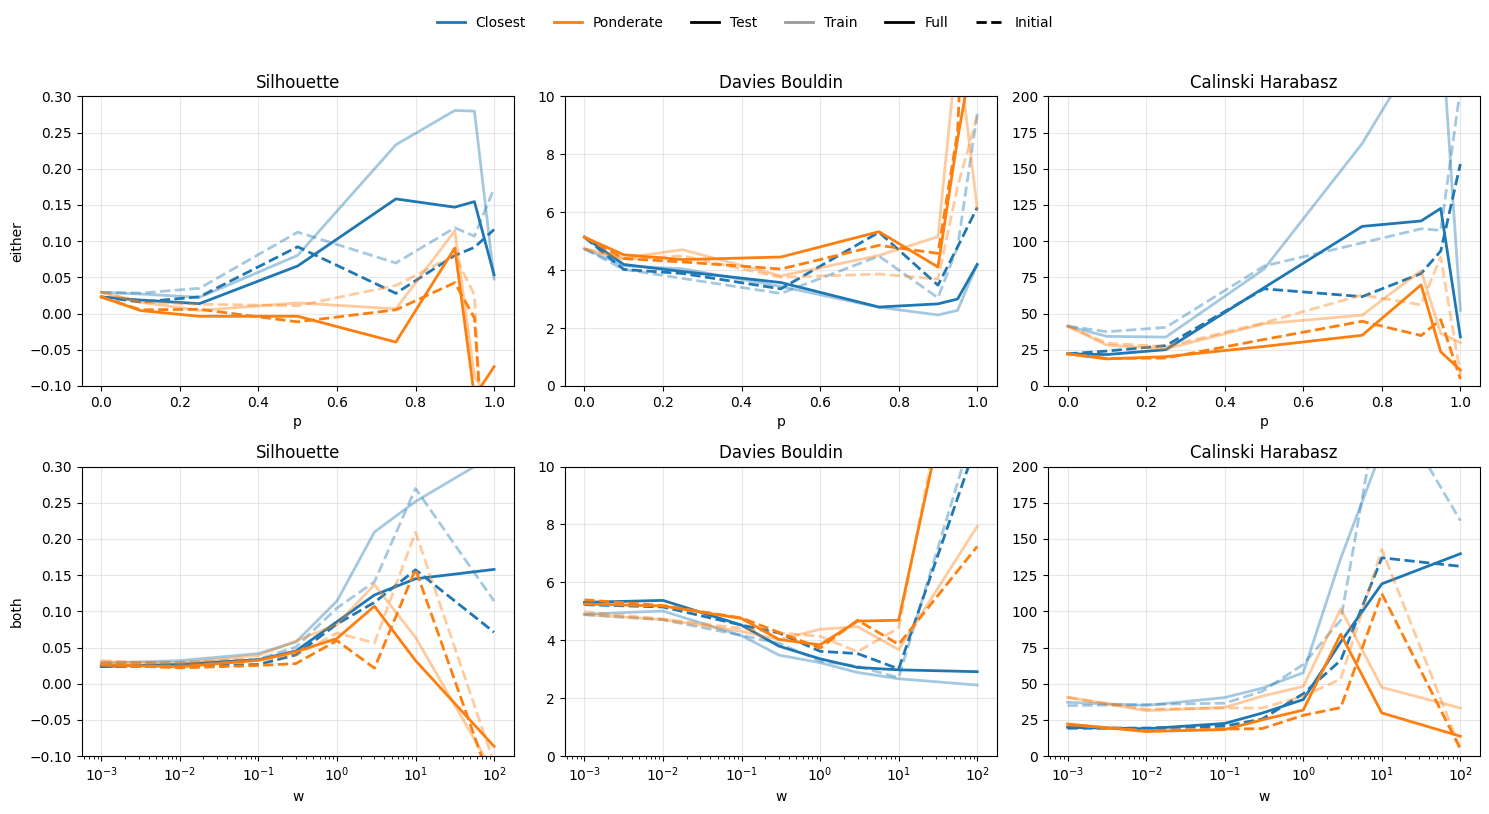

In [ ]:
# -----------------------------------------------------------------------------
# Paths
# -----------------------------------------------------------------------------
cwd = Path.cwd()
if cwd.name == "notebooks":
    outputs_dir = cwd.parent / "outputs"
else:
    outputs_dir = cwd / "outputs"

print(f"Using outputs dir: {outputs_dir}")

# -----------------------------------------------------------------------------
# Parse folders
# -----------------------------------------------------------------------------
metrics_to_plot = ["silhouette", "davies_bouldin", "calinski_harabasz"]
dataset_key = "base_classes"

# We do NOT trust the "both/either" token in the folder name anymore.
# We infer:
#   - "_p..." => either
#   - "_w..." => both
pattern = re.compile(
    r"^run_(both|either)_(closest|ponderate)_(initial|full)_(w|p)([0-9.]+)_s\d+_.*$"
)

raw = {}

for folder in outputs_dir.iterdir():
    if not folder.is_dir():
        continue

    name = folder.name
    if ("initial" not in name) and ("full" not in name):
        continue

    m = pattern.match(name)
    if m is None:
        continue

    _, weighting, scope, param_kind, param_value = m.groups()
    param_value = float(param_value)

    # Infer the true supervision mode from parameter kind
    supervision = "either" if param_kind == "p" else "both"

    json_path = folder / "projection_metrics.json"
    if not json_path.exists():
        print(f"Missing json: {json_path}")
        continue

    with open(json_path, "r") as f:
        d = json.load(f)

    raw.setdefault(supervision, {}).setdefault(weighting, {}).setdefault(scope, [])

    raw[supervision][weighting][scope].append({
        "x": param_value,
        "train": {metric: d["train"][dataset_key][metric] for metric in metrics_to_plot},
        "test": {metric: d["test"][dataset_key][metric] for metric in metrics_to_plot},
        "folder": name,
    })

# Optional check
for supervision in raw:
    for weighting in raw[supervision]:
        for scope in raw[supervision][weighting]:
            xs = sorted(e["x"] for e in raw[supervision][weighting][scope])
            print(f"{supervision:6s} | {weighting:10s} | {scope:7s} | {xs}")

N_train = np.load('../outputs/run_both_closest_initial_p0.1_s97_20260323_1719/embeddings/train_projections.npy').shape[0]
N_test = np.load('../outputs/run_both_closest_initial_p0.1_s97_20260323_1719/embeddings/test_projections.npy').shape[0]
print(N_train, N_test)
# -----------------------------------------------------------------------------
# Plot
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=False)

row_map = {"either": 0, "both": 1}
col_map = {
    "silhouette": 0,
    "davies_bouldin": 1,
    "calinski_harabasz": 2,
}

color_map = {
    "closest": "C0",
    "ponderate": "C1",
}

alpha_map = {
    "train": 0.4,
    "test": 1.0,
}

linestyle_map = {
    "initial": "--",
    "full": "-",
}

ylim_map = {
    "silhouette": [-0.1, 0.3],
    "davies_bouldin": [0, 10],
    "calinski_harabasz": [0,200],
}
    

for supervision in ["either", "both"]:
    for metric in metrics_to_plot:
        ax = axes[row_map[supervision], col_map[metric]]

        for weighting in ["closest", "ponderate"]:
            for scope in ["initial", "full"]:
                entries = raw.get(supervision, {}).get(weighting, {}).get(scope, [])
                if len(entries) == 0:
                    continue

                entries = sorted(entries, key=lambda e: e["x"])
                x = np.array([e["x"] for e in entries])

                for split in ["train", "test"]:
                    y = np.array([e[split][metric] for e in entries])
                    if metric=='calinski_harabasz' and split=='train':
                        y = y *N_test/N_train

                    ax.plot(
                        x, y,
                        color=color_map[weighting],
                        alpha=alpha_map[split],
                        linestyle=linestyle_map[scope],
                        linewidth=2,
                    )

        ax.set_title(metric.replace("_", " ").title())
        ax.grid(True, alpha=0.3)
        ax.set_ylim(ylim_map[metric])
        if supervision == "both":
            ax.set_xscale("log")
            ax.set_xlabel("w")
        else:
            ax.set_xlabel("p")

        if col_map[metric] == 0:
            ax.set_ylabel(supervision)

# -----------------------------------------------------------------------------
# Custom legend (clean & readable)
# -----------------------------------------------------------------------------

legend_elements = [
    Line2D([0], [0], color="C0", lw=2, label="Closest"),
    Line2D([0], [0], color="C1", lw=2, label="Ponderate"),
    Line2D([0], [0], color="black", lw=2, alpha=1.0, label="Test"),
    Line2D([0], [0], color="black", lw=2, alpha=0.4, label="Train"),
    Line2D([0], [0], color="black", lw=2, linestyle="-", label="Full"),
    Line2D([0], [0], color="black", lw=2, linestyle="--", label="Initial"),
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    ncol=6,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### 5.3 Cross-run metric plot
Bar chart comparing silhouette, Davies-Bouldin, and Calinski-Harabasz across user-specified runs. Add paths to `RUN_DIRS` to include additional experiments.

FileNotFoundError: [Errno 2] No such file or directory: '/users/mbredber/p3_SUPLAT/outputs/GOOD_cond_base_20260402_1749/projection_metrics.json'

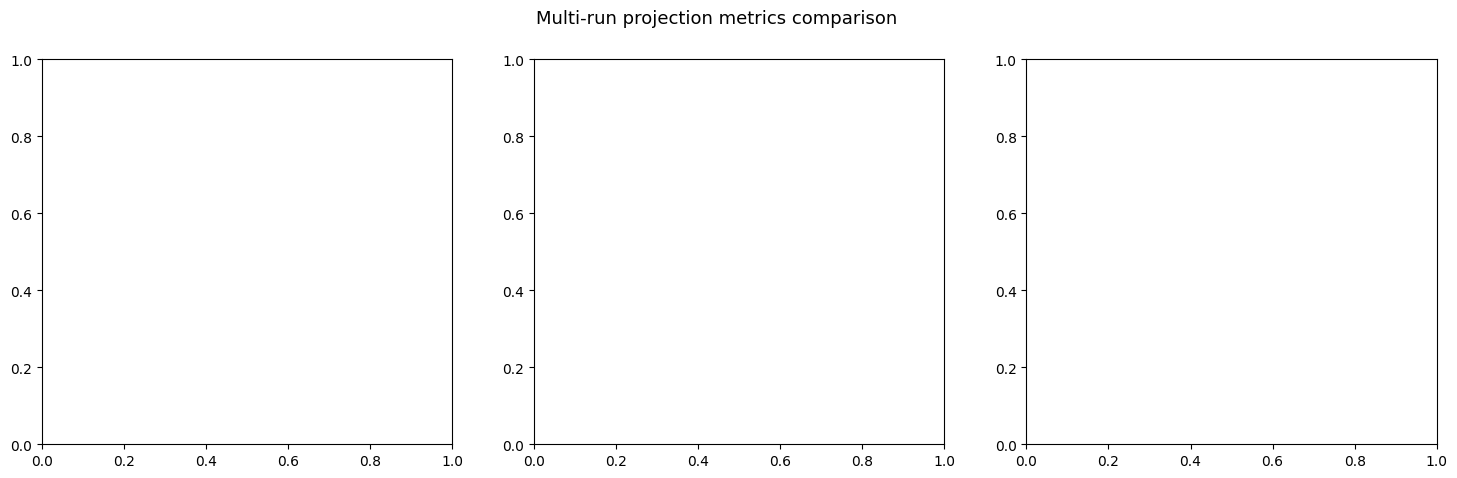

In [75]:
# ── USER CONFIG ──────────────────────────────────────────────────────────────
RUN_DIRS = [
    "/users/mbredber/p3_SUPLAT/outputs/GOOD_cond_base_20260402_1749",
    # add more directories here
]
# ─────────────────────────────────────────────────────────────────────────────

def extract_run_name(path):
    name = Path(path).name
    name = re.sub(r'^(GOOD_|INTERESTING_|run_)', '', name)
    name = re.sub(r'_\d{8}_\d{4}$', '', name)
    return name

METRICS   = ['silhouette', 'davies_bouldin', 'calinski_harabasz']
X_LABELS  = ['train\\nfri_vs_frii', 'train\\nbase_classes',
             'test\\nfri_vs_frii',  'test\\nbase_classes']
X_KEYS    = [('train','fri_vs_frii'), ('train','base_classes'),
             ('test','fri_vs_frii'),  ('test','base_classes')]

colors = plt.cm.tab10.colors
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Multi-run projection metrics comparison', fontsize=13)

for run_idx, run_dir in enumerate(RUN_DIRS):
    metrics_path = Path(run_dir) / 'projection_metrics.json'
    with open(metrics_path) as f:
        data = json.load(f)
    run_name = extract_run_name(run_dir)
    color = colors[run_idx % len(colors)]

    for ax, metric in zip(axes, METRICS):
        values = [data[split][grouping][metric] for split, grouping in X_KEYS]
        ax.plot(range(len(X_KEYS)), values, marker='o', label=run_name, color=color)

for ax, metric in zip(axes, METRICS):
    ax.set_title(metric.replace('_', ' ').title())
    ax.set_xticks(range(len(X_LABELS)))
    ax.set_xticklabels(X_LABELS, fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].legend(bbox_to_anchor=(0, -0.25), loc='upper left', ncol=3, fontsize=9)
fig.tight_layout()
plt.show()
